# Data visualization in Python with Matplotlib & Seaborn

- Over the years, I've collected resources on visualization, it may be useful: https://arghyadutta.github.io/notebooks/visualization.html
- Particularly, check this repository where I wrote some examples of how to create decent plots: https://github.com/arghyadutta/code-i-use/tree/main/plots
- I recommend watching [this video](https://www.youtube.com/watch?v=_2LLXnUdUIc) to learn about colors and [this one](https://www.youtube.com/watch?v=a5KYlHNKQB8) about layout and composition. While the videos are on graphic design, they are helpful for scientific visualization, too.
- For publication-quality plots, you need to be careful with the image size. What you see in a jupyter notebook, will **Not** look the same in a paper. 
- For example, to produce a 3x2 (in square inch) figure, which is roughly the standard size for a single column and single row figure in journals, you need to use this: `fig, ax = plt.subplots(1, figsize=(3, 2))`

In [17]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import pandas as pd

# it's generally a good idea to check the versions of the packages, especially if you're working in collaboration with others.

print(f"Matplotlib version: {mpl.__version__}")
print(f"Seaborn version:    {sns.__version__}")
np.__version__

Matplotlib version: 3.10.8
Seaborn version:    0.13.2


'2.4.2'

## Basics

- `fig` is the whole canvas; `ax` is the individual chart area.
- `label=` and `ax.legend()` create the legend automatically.

There are many options for styling. check documentation! https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

Text(0.5, 1.0, 'My first random plot')

Text(0.5, 0, '$x$')

Text(0, 0.5, 'Amplitude')

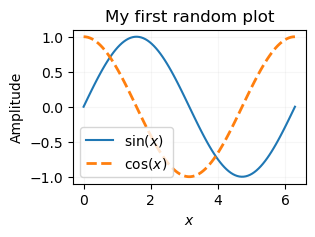

In [56]:

x1 = np.linspace(0, 2 * np.pi, 100)  
y_sin = np.sin(x1)
y_cos = np.cos(x1)

# create figure and axis
fig, ax = plt.subplots(figsize=(3,2))  # (width, height) in inches 

# plot curves 

ax.plot(x1, y_sin, label=r'$\sin(x)$')

# many options to modify the plot
ax.plot(x1, y_cos, label=r'$\cos(x)$', linewidth=2, linestyle='--')

ax.set_title('My first random plot')
ax.set_xlabel('$x$')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.1); # produces a light gray background grid
fig.savefig('p2.pdf')

Text(0.5, 1.0, 'My first random plot')

Text(0.5, 0, '$x$')

Text(0, 0.5, 'Amplitude')

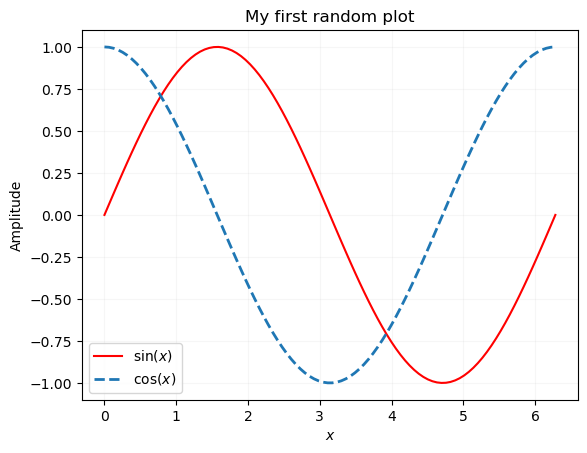

In [54]:
# sometimes for quick plots we don't use figures and axis as mentioned in the previous cell. we just use pyplot options using plt.plot() etc. 
# see here for more: https://matplotlib.org/stable/tutorials/pyplot.html
# for example, the previous plot can be generated as:

plt.plot(x1, y_sin, label=r'$\sin(x)$', color='red')
plt.plot(x1, y_cos, label=r'$\cos(x)$', linewidth=2, linestyle='--')

plt.title('My first random plot') # almost same command, but without the `set_` part.
plt.xlabel('$x$')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=.1); # produces a light gray background grid
plt.savefig('p1.pdf')

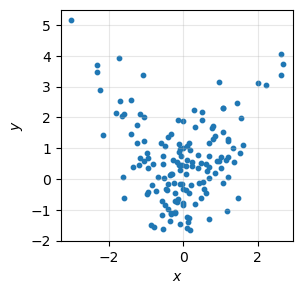

In [71]:
# Scatter plot

x = np.random.randn(150)
y = 0.6 * x**2 + np.random.randn(150)

# x = [1, 2, 3]
# y = [3, 4, 5]
fig, ax = plt.subplots(figsize=(3, 3))

ax.scatter(x, y, s=10)

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.grid(True, alpha=0.3);

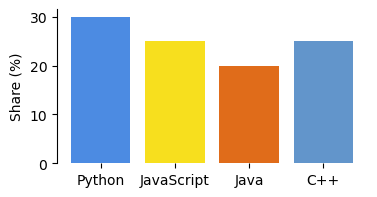

In [72]:
# bar plot

languages = ['Python', 'JavaScript', 'Java', 'C++']
popularity = [30, 25, 20, 25]

# you can set colors by their hex codes. look it up! also check https://yeun.github.io/open-color/ . it's an free resource.
bar_colors = ['#4C8BE2', '#F7DF1E', '#E06C1A', '#6295CB'] 

fig, ax = plt.subplots(figsize=(4, 2))

ax.bar(languages, popularity, color=bar_colors)
ax.set_ylabel('Share (%)')

# almost everything is editable. for example the box boundaries!
ax.spines['top'].set_visible(False)    # hide top border
ax.spines['right'].set_visible(False)  # hide right border
ax.spines['bottom'].set_visible(False);

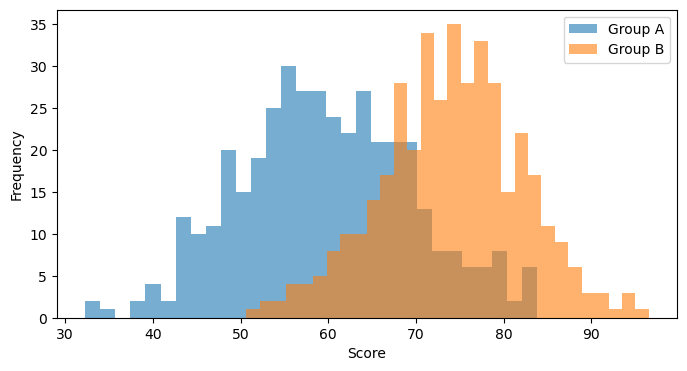

In [22]:
# histogram

np.random.seed(0)
data_a = np.random.normal(loc=60, scale=10, size=400)   # mean=60
data_b = np.random.normal(loc=75, scale=8,  size=400)   # mean=75

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(data_a, bins=30, alpha=0.6, label='Group A')
ax.hist(data_b, bins=30, alpha=0.6,  label='Group B')

ax.set_xlabel('Score')
ax.set_ylabel('Frequency')
ax.legend();

## Multiple Charts in One Figure

`plt.subplots(rows, cols)` returns a grid of axes.

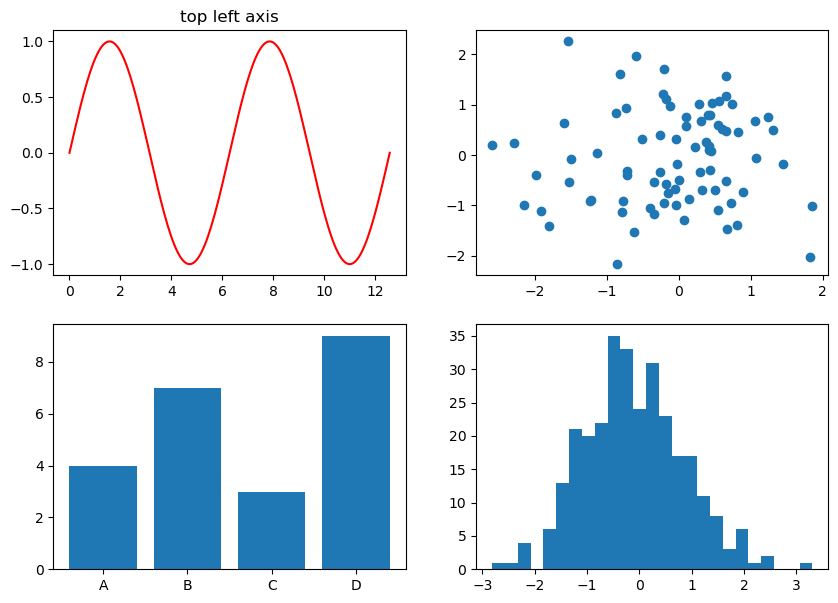

In [60]:
# data for plots
t = np.linspace(0, 4 * np.pi, 200)
cats = ['A', 'B', 'C', 'D']
vals = [4, 7, 3, 9]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# type(axes)
# axes is an numpy array! and it can be indexed as usual

axes[0, 0].plot(t, np.sin(t),c='red')
axes[0, 0].set_title('top left axis')
axes[0, 1].scatter(np.random.randn(80), np.random.randn(80))
axes[1, 0].bar(cats, vals)
axes[1, 1].hist(np.random.randn(300), bins=25);

## Seaborn

Seaborn is built on top of Matplotlib and makes statistical plots much easier. It works great with pandas DataFrames.

In [24]:

tips = sns.load_dataset('tips')   # restaurant tips data, comes in-built with seaborn
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [25]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


<Axes: xlabel='total_bill', ylabel='tip'>

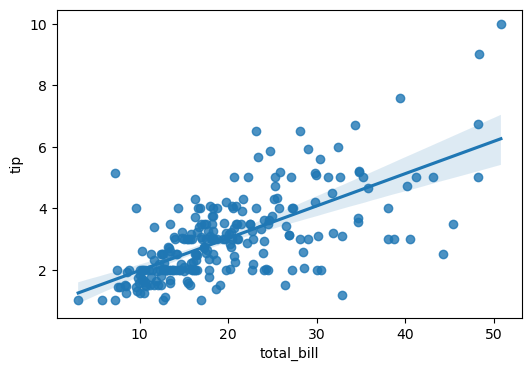

In [26]:
# regression

fig, axes = plt.subplots(1, 1, figsize=(6, 4))

sns.regplot(data=tips, x='total_bill', y='tip', ax=axes)

A pair plot shows all pairwise relationships in one shot. It's magical! :)

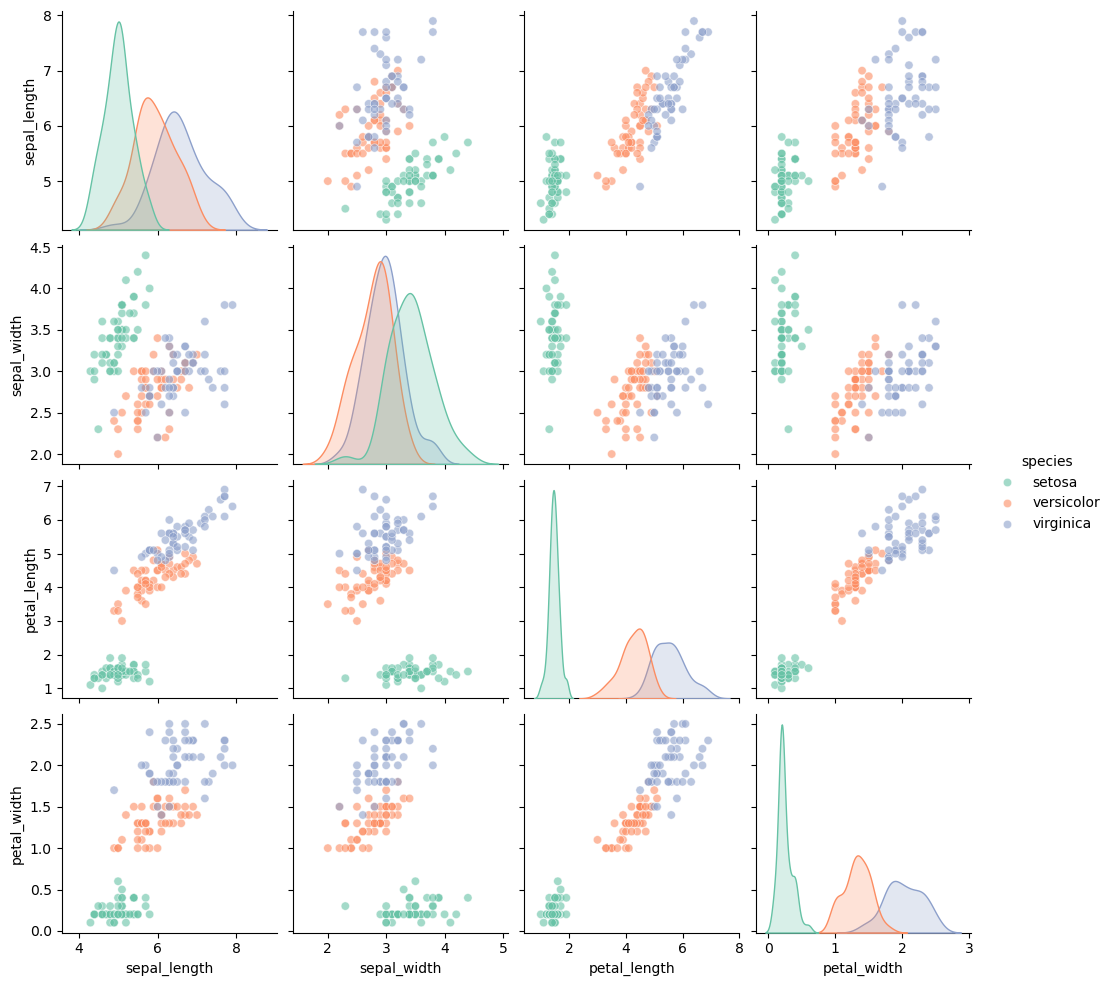

In [27]:
iris = sns.load_dataset('iris')

pair_grid = sns.pairplot(iris, hue='species', palette='Set2',
                         diag_kind='kde', plot_kws={'alpha': 0.6})
plt.show()

saving Figures

Use `fig.savefig()` to export your plots. 

- `dpi=150` or `dpi=300` for high-quality PNGs.
- `bbox_inches='tight'` prevents labels from being cropped.
- Use `.pdf` or `.svg` for print-quality vector graphics.

Text(0.5, 1.0, 'A Simple Chart')

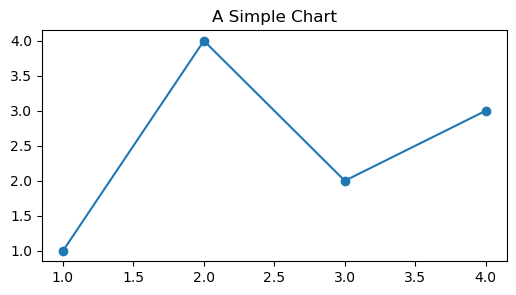

In [28]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot([1, 2, 3, 4], [1, 4, 2, 3], marker='o')
ax.set_title('A Simple Chart')

# Save options
fig.savefig('my_chart.png', dpi=150, bbox_inches='tight')   # PNG  (raster)
fig.savefig('my_chart.pdf', bbox_inches='tight')            # PDF  (vector)
# fig.savefig('my_chart.svg', bbox_inches='tight')            # SVG  (vector)